<a href="https://colab.research.google.com/github/Khalimovgeek/Tensorflow_MINI_PROJECTS/blob/main/NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install tensorflow-datasets

In [3]:
pip install --upgrade --force-reinstall tensorflow-datasets


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.5/186.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.1 MB/s eta 0:00:00


In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, datasets, optimizers, metrics, utils

In [2]:
(ds_train, ds_valid, ds_test), ds_info = tfds.load(
    'conll2003',
    split=['train', 'dev', 'test'],
    shuffle_files=True,
    with_info=True
)

# View dataset structure and total elements
print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating dev examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/conll2003/conll2003/incomplete.WVSUXN_1.0.0/conll2003-dev.tfrecord-[0-9][0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/conll2003/conll2003/incomplete.WVSUXN_1.0.0/conll2003-test.tfrecord-[0-9][…

Dataset conll2003 downloaded and prepared to /root/tensorflow_datasets/conll2003/conll2003/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='conll2003',
    full_name='conll2003/conll2003/1.0.0',
    description="""
    The shared task of CoNLL-2003 concerns language-independent named entity
    recognition and concentrates on four types of named entities: persons,
    locations, organizations and names of miscellaneous entities that do not belong
    to the previous three groups.
    """,
    homepage='https://www.aclweb.org/anthology/W03-0419/',
    data_dir='/root/tensorflow_datasets/conll2003/conll2003/1.0.0',
    file_format=tfrecord,
    download_size=959.94 KiB,
    dataset_size=3.87 MiB,
    features=FeaturesDict({
        'chunks': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=23)),
        'ner': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=9)),
        'pos': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=47)),
        

In [20]:
# Extract tokens and NER labels, and filter out empty sentences
ds_train_tuple = ds_train.map(lambda x: (x['tokens'], x['ner'])).filter(lambda tokens, labels: tf.shape(tokens)[0] > 0)
ds_val_tuple = ds_valid.map(lambda x: (x['tokens'], x['ner'])).filter(lambda tokens, labels: tf.shape(tokens)[0] > 0)

In [21]:
MAX_TOKENS = 10000
SEQUNCE_LEN = 200
vectorize_layer = layers.TextVectorization(max_tokens=MAX_TOKENS,output_mode='int',output_sequence_length=SEQUNCE_LEN, split = None , standardize = None)


In [22]:
# Extract only the text tokens for adaptation
train_text = ds_train_tuple.map(lambda tokens, labels: tokens)
vectorize_layer.adapt(train_text)

In [23]:
import tensorflow as tf

def preprocess_fn(tokens, labels):
    # 1. Add a temporary batch dimension so the vectorizer treats this as ONE sentence
    # Shape changes from (seq_len,) to (1, seq_len)
    expanded_tokens = tf.expand_dims(tokens, axis=0)

    # 2. Vectorize (outputs shape (1, SEQUENCE_LEN))
    vectorized_2d = vectorize_layer(expanded_tokens)

    # 3. Remove the temporary batch dimension (outputs shape (SEQUENCE_LEN,))
    vectorized_tokens = tf.squeeze(vectorized_2d, axis=0)

    # 4. Pad or truncate labels to match SEQUENCE_LEN
    seq_len = tf.shape(labels)[0]
    pad_size = tf.maximum(0, SEQUNCE_LEN - seq_len)
    padded_labels = tf.pad(labels, [[0, pad_size]], constant_values=0)
    final_labels = padded_labels[:SEQUNCE_LEN]

    return vectorized_tokens, final_labels

In [24]:

print(ds_train.cardinality())

tf.Tensor(14042, shape=(), dtype=int64)


In [25]:
# Map the preprocessing function and set batch size
train_dataset = ds_train_tuple.map(preprocess_fn).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = ds_val_tuple.map(preprocess_fn).batch(32).prefetch(tf.data.AUTOTUNE)

In [26]:
def model():
  model = models.Sequential(
      [
          layers.Embedding(input_dim=len(vectorize_layer.get_vocabulary()), output_dim=32, mask_zero=True, input_shape=(SEQUNCE_LEN,)),
          layers.Bidirectional(layers.LSTM(32, return_sequences=True)),
          layers.Bidirectional(layers.LSTM(32, return_sequences=True)),
          layers.Bidirectional(layers.LSTM(32,return_sequences=True)),
          layers.Dense(64, activation='relu'),
          layers.Dropout(0.2),
          layers.Dense(9, activation='softmax'),

      ]

  )
  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
    )
  return model

In [27]:
my_model  = model()
my_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 200, 64)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 200, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 200, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 200, 64)        │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200, 9)         │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,049 (1.49 MB)

 Trainable params: 391,049 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_ner_classifier.keras",
    monitor="val_loss",
    save_best_only=True
)


In [29]:
history = my_model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[
        early_stop,
        checkpoint,
    ]
)

Epoch 1/10
    437/Unknown 17s 28ms/step - accuracy: 0.8238 - loss: 0.9382

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


439/439 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.8341 - loss: 0.7207 - val_accuracy: 0.8624 - val_loss: 0.4308
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8996 - loss: 0.2941 - val_accuracy: 0.9129 - val_loss: 0.2719
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.9401 - loss: 0.1859 - val_accuracy: 0.9392 - val_loss: 0.2083
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9654 - loss: 0.1195 - val_accuracy: 0.9481 - val_loss: 0.1919
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9749 - loss: 0.0882 - val_accuracy: 0.9519 - val_loss: 0.1918
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9784 - loss: 0.0743 - val_accuracy: 0.9543 - val_loss: 0.1886
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9814 - loss: 0.0635 - val_accuracy: 0.9504 - val_loss: 0.2320
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9843 - loss: 0.0539 - val_accurac

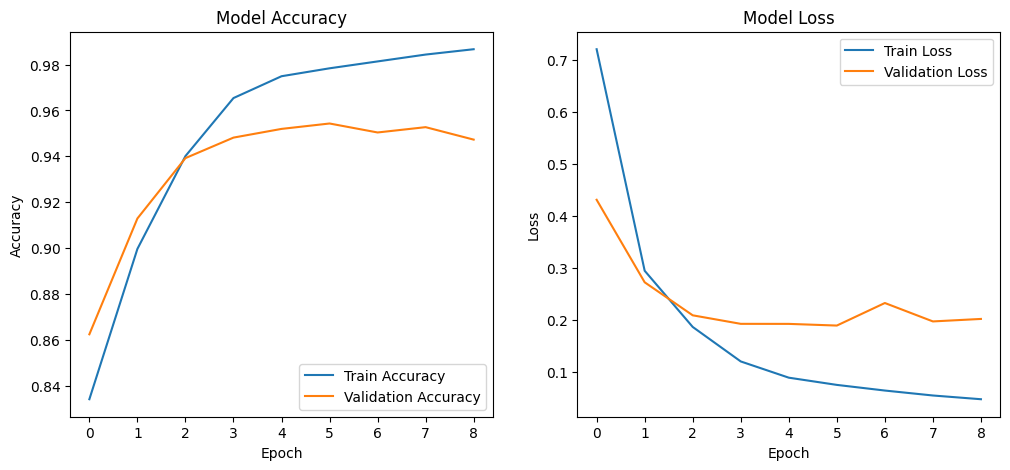

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [31]:
# 1. Map the raw test dataset and filter out empty sentences
ds_test_tuple = ds_test.map(lambda x: (x['tokens'], x['ner'])).filter(lambda tokens, labels: tf.shape(tokens)[0] > 0)

# 2. Run the preprocessing function and batch the data
test_dataset = ds_test_tuple.map(preprocess_fn).batch(32).prefetch(tf.data.AUTOTUNE)

# 3. Evaluate the model on the test dataset
test_loss, test_accuracy = my_model.evaluate(test_dataset)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9352 - loss: 0.2737

Test Loss: 0.2737
Test Accuracy: 0.9352


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [32]:
import numpy as np

# Retrieve vocabulary and tag class names from TFDS info
vocabulary = vectorize_layer.get_vocabulary()
tag_names = ds_info.features['ner'].feature.names  # e.g., ['O', 'B-PER', 'I-PER', ...]

# Take 1 batch from the test dataset to inspect
for x_batch, y_batch in test_dataset.take(1):
    # Predict the probability distributions
    raw_predictions = my_model.predict(x_batch)

    # Get the index of the highest probability for each token
    predicted_ids = np.argmax(raw_predictions, axis=-1)

    # Let's inspect the first 5 sentences in this batch
    for i in range(5):
        print(f"\n--- Sentence {i + 1} ---")
        print(f"{'Word':<15} | {'True Tag':<10} | {'Predicted Tag':<10}")
        print("-" * 43)

        sentence_tokens = x_batch[i].numpy()
        true_tags = y_batch[i].numpy()
        pred_tags = predicted_ids[i]

        for token_id, true_id, pred_id in zip(sentence_tokens, true_tags, pred_tags):
            # Skip padding tokens (the vectorizer maps padding to index 0)
            if token_id == 0:
                continue

            word = vocabulary[token_id]
            true_tag = tag_names[true_id]
            pred_tag = tag_names[pred_id]

            # Print row if it's not padding
            print(f"{word:<15} | {true_tag:<10} | {pred_tag:<10}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- Sentence 1 ---
Word            | True Tag   | Predicted Tag
-------------------------------------------
[UNK]           | B-ORG      | B-ORG     
Milan           | I-ORG      | I-ORG     
(               | O          | O         
Italy           | B-LOC      | B-LOC     
)               | O          | O         
9               | O          | O         
6               | O          | O         
3               | O          | O         
15              | O          | O         

--- Sentence 2 ---
Word            | True Tag   | Predicted Tag
-------------------------------------------
Bowling         | O          | O         
:               | O          | O         
Wasim           | B-PER      | B-PER     
Akram           | I-PER      | I-PER     
[UNK]           | O          | O         
(               | O          | O         
[UNK]           | O          | O         
,               | O          | O         
1nb             | O          | O

In [ ]:
model = models.load('best_ner_classifier.keras')


In [33]:
import re
import numpy as np
import tensorflow as tf

# Retrieve your vocabulary and tag class names if not already in memory
vocabulary = vectorize_layer.get_vocabulary()
tag_names = ds_info.features['ner'].feature.names  # ['O', 'B-PER', 'I-PER', ...]

def predict_custom_sentence(sentence_str, model, vectorize_layer, tag_names):
    # 1. Cleanly split words and punctuation (e.g., "Google." -> ["Google", "."])
    tokens = re.findall(r"\w+|[^\w\s]", sentence_str)

    # 2. Convert to a TensorFlow string tensor
    tokens_tensor = tf.constant(tokens)

    # 3. Add batch dimension (1, seq_len) and run through vectorize_layer
    vectorized_input = vectorize_layer(tf.expand_dims(tokens_tensor, axis=0))

    # 4. Run model inference
    predictions = model.predict(vectorized_input)

    # 5. Get predicted class IDs for the first batch item
    predicted_ids = np.argmax(predictions, axis=-1)[0]

    # 6. Print the results
    print(f"\n--- Custom Prediction for: '{sentence_str}' ---")
    print(f"{'Token':<15} | {'Predicted Tag':<15}")
    print("-" * 35)

    # Zipping with 'tokens' automatically ignores trailing padding tokens (beyond seq_len)
    for token, pred_id in zip(tokens, predicted_ids):
        pred_tag = tag_names[pred_id]
        print(f"{token:<15} | {pred_tag:<15}")

# --- Run the Custom Inference ---
test_sentences = [
    "Elon Musk announced that SpaceX will launch a new rocket from Cape Canaveral.",
    "Yesterday, Sundar Pichai attended a technology conference in Munich to represent Google.",
    "The United Nations will meet in Geneva to discuss the European trade agreement."
]

for sentence in test_sentences:
    predict_custom_sentence(sentence, my_model, vectorize_layer, tag_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step

--- Custom Prediction for: 'Elon Musk announced that SpaceX will launch a new rocket from Cape Canaveral.' ---
Token           | Predicted Tag  
-----------------------------------
Elon            | O              
Musk            | O              
announced       | O              
that            | O              
SpaceX          | B-LOC          
will            | O              
launch          | O              
a               | O              
new             | O              
rocket          | O              
from            | O              
Cape            | O              
Canaveral       | O              
.               | O              
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

--- Custom Prediction for: 'Yesterday, Sundar Pichai attended a technology conference in Munich to represent Google.' ---
Token           | Predicted Tag  
-----------------------------------
Yesterday       | O              
,               | O              
Sund